In [1]:
!pip install roboflow --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 285.0/285.0 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 49.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 90.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 3.9 MB/s eta 0:00:00


In [3]:
from roboflow import Roboflow
rf = Roboflow(api_key="xysyfY8qoeP7gafx6WnB")
project = rf.workspace("ahmeds-workspace-1857d").project("entrainement-sojwl-acr00")
version = project.version(1)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Entrainement-1 in yolov8:: 100%|██████████| 3075/3075 [00:00<00:00, 3775.80it/s]


In [4]:
import os
import glob
import yaml

dataset_path = dataset.location
yaml_path = os.path.join(dataset_path, "data.yaml")

# Read the original YAML
with open(yaml_path, 'r') as f:
    dataset_yaml = yaml.safe_load(f)

# 1. Dynamically build the mapping based on text names, not guessed integers
dynamic_mapping = {}
original_classes = dataset_yaml['names']

# Handle both list and dictionary formats from YAML
items = enumerate(original_classes) if isinstance(original_classes, list) else original_classes.items()

for old_id, class_name in items:
    name_lower = class_name.lower()

    if name_lower in ['ball', 'football']:
        dynamic_mapping[old_id] = 0
    elif name_lower in ['player', 'goalkeeper', 'goalie', 'ned', 'usa']:
        dynamic_mapping[old_id] = 1
    elif name_lower in ['referee', 'ref']:
        dynamic_mapping[old_id] = 2
    # The 'goal' class is automatically ignored/deleted because it's not in these lists

# 2. Update all YOLO .txt label files
label_files = glob.glob(os.path.join(dataset_path, "**", "labels", "*.txt"), recursive=True)

for file_path in label_files:
    with open(file_path, "r") as file:
        lines = file.readlines()

    new_lines = []
    for line in lines:
        parts = line.strip().split()
        if not parts: continue

        old_id = int(parts[0])
        if old_id in dynamic_mapping:
            parts[0] = str(dynamic_mapping[old_id])
            new_lines.append(" ".join(parts) + "\n")

    with open(file_path, "w") as file:
        file.writelines(new_lines)

# 3. Overwrite data.yaml with the clean 3-class structure
dataset_yaml['nc'] = 3
dataset_yaml['names'] = ['ball', 'player', 'referee']

with open(yaml_path, 'w') as f:
    yaml.dump(dataset_yaml, f)

print(f"Success! Cleaned {len(label_files)} files using dynamic text mapping.")

Success! Cleaned 1535 files using dynamic text mapping.


In [5]:
import os
import glob
import yaml
from collections import Counter

dataset_path = dataset.location
yaml_path = os.path.join(dataset_path, "data.yaml")

# 1. Verify the YAML Configuration
with open(yaml_path, 'r') as f:
    dataset_yaml = yaml.safe_load(f)

print("--- YAML CONFIGURATION ---")
print(f"Number of classes declared: {dataset_yaml.get('nc')}")
print(f"Class names: {dataset_yaml.get('names')}\n")

# 2. Verify the .txt Label Files
label_files = glob.glob(os.path.join(dataset_path, "**", "labels", "*.txt"), recursive=True)
all_ids = []

for file_path in label_files:
    with open(file_path, "r") as file:
        for line in file:
            parts = line.strip().split()
            if parts:
                # The first number in the YOLO format is the class ID
                all_ids.append(int(parts[0]))

print("--- LABEL DISTRIBUTION ---")
id_counts = Counter(all_ids)
total_instances = len(all_ids)

# Print the exact count of each class ID found in the files
for class_id in sorted(id_counts.keys()):
    # Get the string name if the ID is valid, otherwise flag it
    name = dataset_yaml['names'][class_id] if class_id < dataset_yaml.get('nc', 0) else "UNKNOWN/ERROR"
    count = id_counts[class_id]
    percentage = (count / total_instances) * 100
    print(f"ID {class_id} ({name}): {count} bounding boxes ({percentage:.1f}%)")

# 3. Final Health Check
invalid_ids = [cid for cid in id_counts.keys() if cid not in [0, 1, 2]]

print("\n--- FINAL VERDICT ---")
if invalid_ids:
    print(f"❌ ERROR: Found invalid class IDs still lingering in the files: {invalid_ids}")
elif not id_counts:
    print("❌ ERROR: No labels found at all! The dataset might be empty.")
else:
    print("✅ SUCCESS: The dataset is perfectly clean! You are ready to train.")

--- YAML CONFIGURATION ---
Number of classes declared: 3
Class names: ['ball', 'player', 'referee']

--- LABEL DISTRIBUTION ---
ID 0 (ball): 1028 bounding boxes (3.6%)
ID 1 (player): 24995 bounding boxes (88.3%)
ID 2 (referee): 2283 bounding boxes (8.1%)

--- FINAL VERDICT ---
✅ SUCCESS: The dataset is perfectly clean! You are ready to train.


In [6]:
# Install YOLOv8
!pip install ultralytics==8.2.103 -q
!yolo settings sync=False

# Train the model using the CLI interface
!yolo task=detect mode=train model=yolov8n.pt data={dataset.location}/data.yaml epochs=50 imgsz=640

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 875.1/875.1 kB 58.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 103.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 13.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
shap 0.52.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.3 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=

In [12]:
# Fix numpy dependency conflicts
!pip uninstall numpy -y
!pip uninstall torchvision -y
!pip uninstall ultralytics -y

# Install a compatible numpy version, then reinstall torchvision and ultralytics
!pip install numpy==1.26.4 --quiet
!pip install torchvision --quiet
!pip install ultralytics==8.2.103 --quiet

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
Found existing installation: torchvision 0.26.0+cu128
Uninstalling torchvision-0.26.0+cu128:
  Successfully uninstalled torchvision-0.26.0+cu128
Found existing installation: ultralytics 8.2.103
Uninstalling ultralytics-8.2.103:
  Successfully uninstalled ultralytics-8.2.103
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
fastai 2.8.7 requires torchvision>=0.11, which is not installed.
shap 0.52.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.3 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
xarra

In [ ]:
import os

# Force install a compatible 1.x version of numpy
!pip install "numpy<2" -q

# Automatically kill and restart the Colab runtime to clear the memory
print("Restarting runtime to apply changes...")
os.kill(os.getpid(), 9)


image 1/1 /content/test.jpg: 736x1280 1 ball, 24 players, 1 referee, 40.4ms
Speed: 6.6ms preprocess, 40.4ms inference, 1.7ms postprocess per image at shape (1, 3, 736, 1280)


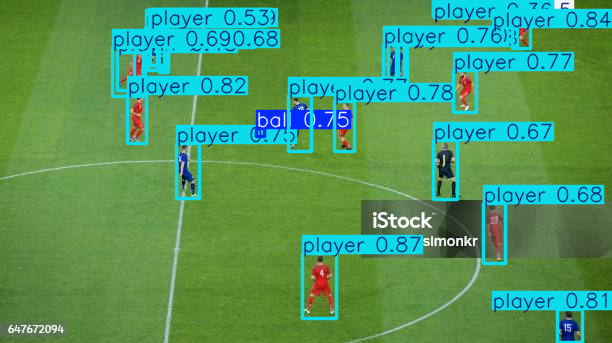

In [8]:
from ultralytics import YOLO
from google.colab.patches import cv2_imshow

# 1. Load your newly trained model
model = YOLO('/content/runs/detect/train/weights/best.pt')

# 2. Define the path to your image
image_path = '/content/test.jpg'

# 3. Run prediction with custom parameters designed for small objects
# We increase imgsz to stop the ball from blurring, and lower conf to catch it
results = model.predict(image_path, imgsz=1280, conf=0.15)

# 4. Extract the annotated image array with the bounding boxes
annotated_frame = results[0].plot()

# 5. Display the result inline in Colab
cv2_imshow(annotated_frame)

In [2]:
from google.colab import files

# YOLOv8 automatically saves the new best weights to this specific path
model_path = '/content/runs/detect/train/weights/best.pt'

# Trigger the browser download
files.download(model_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>